# 🎯 Ederest — Edge Vision for On-Prem ERP
## Pipeline End-to-End : SAP Screenshot → JSON Ederest

**Pipeline :**
```
events.json + screenshots (snooping tool)
        ↓
YOLOv11s  → détection éléments UI
        ↓
EasyOCR   → extraction textes (labels + values)
        ↓
Post-processing → enrichissement par type d'élément
        ↓
JSON format Ederest (PracticeSession → PracticeField)
```

---
## Installation des dépendances

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install ultralytics easyocr -q
print('Dépendances installées !')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 17.5 MB/s eta 0:00:00
Dépendances installées !


---
## Imports

In [3]:
import os
import cv2
import json
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import easyocr
from ultralytics import YOLO

print('Imports OK')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Imports OK


---
## Configuration

In [4]:
# ============================================================
# CHEMINS — à modifier selon ton Drive
# ============================================================
YOLO_MODEL_PATH = '/content/drive/MyDrive/ederest_v6_best.pt'
SCREENSHOTS_DIR = '/content/drive/MyDrive/PAbatchesfolder/test_pipeline_3/'
EVENTS_PATH     = '/content/drive/MyDrive/PAbatchesfolder/test_pipeline_3/events.json'
OUTPUT_JSON     = '/content/drive/MyDrive/PAbatchesfolder/test_pipeline_3/simulation_ederest.json'
SAVE_DIR        = '/content/drive/MyDrive/PAbatchesfolder/pipeline_outputs/'

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(f'{SAVE_DIR}/visualizations/', exist_ok=True)
os.makedirs(f'{SAVE_DIR}/yolo_outputs/', exist_ok=True)
os.makedirs(f'{SAVE_DIR}/jsons/', exist_ok=True)

CLASSES = ['button', 'checkbox', 'dropdown', 'radio button', 'textbox', 'popup']

TYPE_MAPPING = {
    'button'      : 'button',
    'textbox'     : 'text',
    'dropdown'    : 'dropdown',
    'checkbox'    : 'checkbox',
    'radio button': 'checkbox',
    'popup'       : 'button',
}

COLORS = {
    'button'      : '#FF6B6B',
    'checkbox'    : '#4ECDC4',
    'dropdown'    : '#45B7D1',
    'radio button': '#96CEB4',
    'textbox'     : '#FFEAA7',
    'popup'       : '#DDA0DD'
}

print('Configuration OK')
print(f'   YOLO model : {YOLO_MODEL_PATH}')
print(f'   Screenshots: {SCREENSHOTS_DIR}')
print(f'   Events     : {EVENTS_PATH}')
print(f'   Output     : {OUTPUT_JSON}')

Configuration OK
   YOLO model : /content/drive/MyDrive/ederest_v6_best.pt
   Screenshots: /content/drive/MyDrive/PAbatchesfolder/test_pipeline/
   Events     : /content/drive/MyDrive/PAbatchesfolder/test_pipeline/events.json
   Output     : /content/drive/MyDrive/PAbatchesfolder/test_pipeline/simulation_ederest.json


---
## Chargement des modèles YOLO + EasyOCR

In [5]:
yolo   = YOLO(YOLO_MODEL_PATH)
print(f'YOLO chargé : {YOLO_MODEL_PATH}')

reader = easyocr.Reader(['fr', 'en'], gpu=True)
print('EasyOCR chargé (fr + en, GPU)')

YOLO chargé : /content/drive/MyDrive/ederest_v6_best.pt
Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteEasyOCR chargé (fr + en, GPU)


---
## Fonctions OCR

In [6]:
def ocr_full_screen(image_path):
    result      = reader.readtext(image_path)
    text_blocks = []
    for (bbox, text, confidence) in result:
        if confidence < 0.5:
            continue
        x1 = int(min(p[0] for p in bbox))
        y1 = int(min(p[1] for p in bbox))
        x2 = int(max(p[0] for p in bbox))
        y2 = int(max(p[1] for p in bbox))
        text_blocks.append({
            'text'      : text,
            'bbox'      : [x1, y1, x2, y2],
            'confidence': round(confidence, 3),
            'center'    : [(x1+x2)//2, (y1+y2)//2]
        })
    return text_blocks


def merge_nearby_text_blocks(text_blocks, max_gap=8):
    if not text_blocks:
        return text_blocks
    sorted_blocks = sorted(text_blocks, key=lambda b: (b['center'][1], b['center'][0]))
    merged = []
    used   = set()
    for i, block in enumerate(sorted_blocks):
        if i in used:
            continue
        current_text = block['text']
        current_bbox = block['bbox'].copy()
        current_y    = block['center'][1]
        used.add(i)
        for j, other in enumerate(sorted_blocks):
            if j in used or j == i:
                continue
            if abs(other['center'][1] - current_y) > 8:
                continue
            gap = other['bbox'][0] - current_bbox[2]
            if 0 <= gap <= max_gap:
                current_text    += ' ' + other['text']
                current_bbox[2]  = other['bbox'][2]
                current_bbox[3]  = max(current_bbox[3], other['bbox'][3])
                used.add(j)
        merged.append({
            'text'      : current_text,
            'bbox'      : current_bbox,
            'confidence': block['confidence'],
            'center'    : [(current_bbox[0]+current_bbox[2])//2,
                           (current_bbox[1]+current_bbox[3])//2]
        })
    return merged


print('Fonctions OCR définies')

Fonctions OCR définies


---
## Fonctions YOLO

In [7]:
def yolo_detect(image_path):
    results    = yolo.predict(image_path, conf=0.3, verbose=False)
    detections = results[0].boxes
    elements   = []
    for box in detections:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        class_id        = int(box.cls[0])
        confidence      = float(box.conf[0])
        elements.append({
            'type'      : CLASSES[class_id],
            'bbox'      : [x1, y1, x2, y2],
            'confidence': round(confidence, 3),
            'center'    : [(x1+x2)//2, (y1+y2)//2],
            'label'     : '',
            'value'     : ''
        })
    return elements


def screens_are_similar(screen1_path, screen2_path, threshold=0.97):
    img1 = cv2.imread(screen1_path, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(screen2_path, cv2.IMREAD_GRAYSCALE)
    img1 = cv2.resize(img1, (320, 240))
    img2 = cv2.resize(img2, (320, 240))
    diff       = cv2.absdiff(img1, img2)
    similarity = 1 - (np.sum(diff) / (img1.size * 255))
    return similarity > threshold


print('Fonctions YOLO définies')

Fonctions YOLO définies


---
## Fonctions Post-processing

In [15]:
def find_value(el, text_blocks):
    x1, y1, x2, y2 = el['bbox']
    inside = []
    for tb in text_blocks:
        tcx, tcy = tb['center']
        if x1 < tcx < x2 and y1 < tcy < y2:
            inside.append(tb['text'])
    return ' '.join(inside).strip()


def find_label(el, text_blocks):
    x1, y1, x2, y2 = el['bbox']
    el_height  = y2 - y1
    center_y   = (y1 + y2) / 2
    best_label = ''
    min_dist   = float('inf')
    for tb in text_blocks:
        tx1, ty1, tx2, ty2 = tb['bbox']
        tcx = (tx1 + tx2) / 2
        tcy = (ty1 + ty2) / 2
        is_left     = tcx < x1
        not_below   = tcy <= center_y + 5
        same_line   = abs(tcy - center_y) < el_height * 0.6
        not_too_far = (x1 - tcx) < 300
        if is_left and not_below and same_line and not_too_far:
            dist = x1 - tcx
            if dist < min_dist:
                min_dist   = dist
                best_label = tb['text']
    return best_label


def enrich_elements(yolo_elements, text_blocks_raw, text_blocks_merged):
    for el in yolo_elements:
        t = el['type']
        if t == 'button':
            el['value'] = find_value(el, text_blocks_raw)
            el['label'] = ''
        elif t == 'textbox':
            el['label'] = find_label(el, text_blocks_merged)
            el['value'] = find_value(el, text_blocks_raw)
        elif t == 'dropdown':
            el['label'] = find_label(el, text_blocks_merged)
            el['value'] = find_value(el, text_blocks_raw)
        elif t in ['checkbox', 'radio button']:
            el['label'] = find_label(el, text_blocks_merged)
            el['value'] = ''
        elif t == 'popup':
            el['value'] = find_value(el, text_blocks_raw)
            el['label'] = ''
    return yolo_elements


def filter_elements_in_popup(elements):
    popups = [el for el in elements if el['type'] == 'popup']
    if not popups:
        return elements
    popup = max(popups, key=lambda p:
                (p['bbox'][2]-p['bbox'][0]) * (p['bbox'][3]-p['bbox'][1]))
    px1, py1, px2, py2 = popup['bbox']
    filtered = [popup]
    for el in elements:
        if el['type'] == 'popup':
            continue
        cx, cy = el['center']
        if px1 <= cx <= px2 and py1 <= cy <= py2:
            filtered.append(el)
    return filtered


print('Fonctions post-processing définies')

Fonctions post-processing définies


---
## Fonctions Visualisation + Sauvegarde

In [16]:
def visualize(image_path, elements, save=True):
    img = Image.open(image_path).convert('RGB')
    fig, ax = plt.subplots(1, 1, figsize=(18, 10))
    ax.imshow(img)
    for el in elements:
        x1, y1, x2, y2 = el['bbox']
        color = COLORS.get(el['type'], '#FFFFFF')
        rect  = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=2, edgecolor=color,
                                   facecolor=color, alpha=0.25)
        ax.add_patch(rect)
        display_text = el['value'] if el['value'] else el['label']
        display_text = f"[{el['type']}] {display_text[:20]}"
        ax.text(x1, y1-5, display_text, fontsize=7, color='white',
                bbox=dict(facecolor=color, alpha=0.8, pad=1, edgecolor='none'))
    ax.axis('off')
    ax.set_title(image_path.split('/')[-1], fontsize=10)
    plt.tight_layout()
    if save:
        screen_name = image_path.split('/')[-1].replace('.png','').replace('.jpg','')
        out_path    = f"{SAVE_DIR}/visualizations/{screen_name}_viz.png"
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
        print(f"   Visualisation sauvegardée : {out_path}")
    plt.show()
    plt.close()


def save_yolo_visualization(image_path, elements):
    img = cv2.imread(image_path)
    COLORS_BGR = {
        'button': (0,0,255), 'checkbox': (255,200,0),
        'dropdown': (255,165,0), 'radio button': (0,255,0),
        'textbox': (0,255,255), 'popup': (255,0,255)
    }
    for el in elements:
        x1, y1, x2, y2 = el['bbox']
        color   = COLORS_BGR.get(el['type'], (255,255,255))
        display = f"[{el['type']}] {(el['value'] or el['label'])[:15]}"
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.rectangle(img, (x1, y1-20), (x1+len(display)*7, y1), color, -1)
        cv2.putText(img, display, (x1, y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255,255,255), 1)
    screen_name = image_path.split('/')[-1].replace('.png','').replace('.jpg','')
    out_path    = f"{SAVE_DIR}/yolo_outputs/{screen_name}_yolo.jpg"
    cv2.imwrite(out_path, img)
    print(f"   YOLO output sauvegardé : {out_path}")


def visualize_clicked(image_path, all_elements, clicked_element, step_num):
    img = Image.open(image_path).convert('RGB')
    fig, ax = plt.subplots(1, 1, figsize=(16, 9))
    ax.imshow(img)
    for el in all_elements:
        x1, y1, x2, y2 = el['bbox']
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                  linewidth=1, edgecolor='gray',
                                  facecolor='gray', alpha=0.1)
        ax.add_patch(rect)
    if clicked_element:
        x1, y1, x2, y2 = clicked_element['bbox']
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                  linewidth=3, edgecolor='red',
                                  facecolor='red', alpha=0.3)
        ax.add_patch(rect)
        label = clicked_element['label'] or clicked_element['value'] or clicked_element['type']
        ax.text(x1, y1-8, f"CLIQUÉ: [{clicked_element['type']}] {label}",
                fontsize=9, color='white',
                bbox=dict(facecolor='red', alpha=0.9, pad=2, edgecolor='none'))
    ax.axis('off')
    ax.set_title(f"Step {step_num} — {image_path.split('/')[-1]}", fontsize=10)
    plt.tight_layout()
    screen_name = image_path.split('/')[-1].replace('.png','').replace('.jpg','')
    out_path    = f"{SAVE_DIR}/visualizations/{screen_name}_step{step_num}_clicked.png"
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()


print('Fonctions visualisation définies')

Fonctions visualisation définies


---
## Pipeline principal (analyze_screenshot_smart)

In [17]:
def analyze_screenshot_smart(image_path, prev_image_path=None,
                              cached_elements=None, show_viz=False, save=True):
    print(f"\nAnalyse : {image_path.split('/')[-1]}")
    text_blocks_raw    = ocr_full_screen(image_path)
    text_blocks_merged = merge_nearby_text_blocks(text_blocks_raw, max_gap=8)
    print(f"   OCR : {len(text_blocks_raw)} blocs bruts → {len(text_blocks_merged)} blocs mergés")
    if (prev_image_path is not None and
        cached_elements is not None and
        screens_are_similar(prev_image_path, image_path)):
        print(f"   YOLO skippé — layout similaire, cache réutilisé")
        elements = cached_elements
    else:
        print(f"   YOLO lancé — nouveau layout détecté")
        elements = yolo_detect(image_path)
        print(f"   YOLO : {len(elements)} éléments détectés")
    elements = enrich_elements(elements, text_blocks_raw, text_blocks_merged)
    elements = filter_elements_in_popup(elements)
    elements = [el for el in elements if el['confidence'] >= 0.45]
    print(f"\n   {'Type':<15} {'Label':<30} {'Value':<25} {'Conf'}")
    print(f"   {'-'*80}")
    for el in elements:
        print(f"   {el['type']:<15} {el['label']:<30} {el['value']:<25} {el['confidence']}")
    if save:
        save_yolo_visualization(image_path, elements)
        screen_name = image_path.split('/')[-1].replace('.png','').replace('.jpg','')
        json_out    = f"{SAVE_DIR}/jsons/{screen_name}_elements.json"
        with open(json_out, 'w', encoding='utf-8') as f:
            json.dump(elements, f, ensure_ascii=False, indent=2)
        print(f"   Elements JSON sauvegardé : {json_out}")
    if show_viz:
        visualize(image_path, elements, save=save)
    return elements, text_blocks_raw, text_blocks_merged


print('analyze_screenshot_smart défini')

analyze_screenshot_smart défini


---
## ✅ Génération JSON Ederest — VERSION MISE À JOUR

**Changements par rapport à la version précédente :**
- Chaque InteractiveImage contient **TOUS les fields** du screenshot (pas juste le field cliqué)
- `active=True` seulement pour le field cliqué à cette étape, `active=False` pour les autres
- `order` = position constante du field dans la séquence (déterminée en Pass 1 via l'ordre des clics)
- `correct_answers` rempli seulement si `active=True` ET step type (textbox/dropdown)
- Collections séparées quand le layout change (cache YOLO invalidé)

In [21]:
def bbox_to_percent(bbox, img_width, img_height):
    x1, y1, x2, y2 = bbox
    return {
        'x'            : round((x1 / img_width)       * 100, 2),
        'y'            : round((y1 / img_height)      * 100, 2),
        'width'        : round(((x2-x1) / img_width)  * 100, 2),
        'height'       : round(((y2-y1) / img_height) * 100, 2),
        'canvas_width' : img_width,
        'canvas_height': img_height
    }


def find_clicked_element(elements, click_x, click_y):
    closest  = None
    min_dist = float('inf')
    for el in elements:
        cx, cy = el['center']
        dist   = ((cx - click_x)**2 + (cy - click_y)**2) ** 0.5
        if dist < min_dist:
            min_dist = dist
            closest  = el
    return closest


def find_same_element(original_el, next_elements):
    ox1, oy1, ox2, oy2 = original_el['bbox']
    o_center_x = (ox1 + ox2) / 2
    o_center_y = (oy1 + oy2) / 2
    best     = None
    min_dist = float('inf')
    for el in next_elements:
        if el['type'] != 'textbox':
            continue
        if el['label'] != original_el['label']:
            continue
        cx, cy = el['center']
        dist   = ((cx - o_center_x)**2 + (cy - o_center_y)**2) ** 0.5
        if dist < min_dist and dist < 50:
            min_dist = dist
            best     = el
    return best


def get_element_key(el):
    """Clé unique pour identifier un élément (utilisée pour l'order map)."""
    return el['label'] or el['value'] or f"{el['type']}_{el['center'][0]}_{el['center'][1]}"


# def build_order_map(events, screenshots_dir, all_elements_cache):
#     """
#     PASS 1 — Construit le dictionnaire {element_key: order}
#     en parcourant l'ordre des clics dans events.json.
#     L'order d'un field = l'index de l'event où ce field a été cliqué.
#     Un field non cliqué reçoit order=999.
#     """
#     order_map     = {}
#     order_counter = 0
#     for i, event in enumerate(events):
#         elements = all_elements_cache.get(i, [])
#         clicked  = find_clicked_element(elements, event['x'], event['y'])
#         if clicked:
#             key = get_element_key(clicked)
#             if key not in order_map:
#                 order_map[key] = order_counter
#                 order_counter += 1
#     return order_map

def build_order_map_per_collection(events, screenshots_dir, all_elements_cache):
    """
    Construit un order_map PAR COLLECTION.
    Retourne une liste de dicts : [{key: order}, {key: order}, ...]
    Un par collection.
    """
    order_maps        = []
    current_order_map = {}
    order_counter     = 0
    prev_screen       = None

    for i, event in enumerate(events):
        current_screen = os.path.join(screenshots_dir, event['screenshot'])

        # Nouvelle collection → nouveau order_map
        if prev_screen and not screens_are_similar(prev_screen, current_screen):
            order_maps.append(current_order_map)
            current_order_map = {}   # ← reset
            order_counter     = 0    # ← repart de 0

        elements = all_elements_cache.get(i, [])
        clicked  = find_clicked_element(elements, event['x'], event['y'])

        if clicked:
            key = get_element_key(clicked)
            if key not in current_order_map:
                current_order_map[key] = order_counter
                order_counter += 1

        prev_screen = current_screen

    # Ajouter le dernier order_map
    if current_order_map:
        order_maps.append(current_order_map)

    return order_maps


def build_all_fields(elements, clicked_el, order_map, img_w, img_h,
                     step_idx, is_type_step=False, typed_value=None):
    """
    Construit la liste de TOUS les fields d'un InteractiveImage.

    Pour chaque élément détecté par YOLO :
    - active=True  : seulement pour l'élément cliqué à cette étape
    - active=False : tous les autres éléments visibles
    - order        : constant pour chaque field (déterminé en Pass 1)
    - correct_answers : rempli seulement si active=True ET is_type_step
    """
    fields = []
    for j, el in enumerate(elements):
        is_active  = (el is clicked_el)
        key        = get_element_key(el)
        order      = order_map.get(key, 999)
        position   = bbox_to_percent(el['bbox'], img_w, img_h)
        name       = el['label'] or el['value'] or el['type']
        field_type = TYPE_MAPPING.get(el['type'], 'button')

        # correct_answers : rempli seulement si actif + type step
        if is_active and is_type_step and typed_value:
            correct_answers = [typed_value]
            check_response  = True
        else:
            correct_answers = []
            check_response  = False

        # instruction : seulement pour le field actif
        if is_active and not is_type_step:
            instruction = f"Cliquez sur {el['value'] or el['label'] or el['type']}"
        elif is_active and is_type_step:
            instruction = f"Tapez {typed_value}"
        else:
            instruction = ''

        fields.append({
            'field_id'  : f'step_{step_idx}_field_{j}',
            'name'      : name,
            'field_type': field_type,
            'active'    : is_active,
            'colored'   : is_active,
            'required'  : True,
            'order'     : order,
            'position'  : position,
            'field_data': {
                'description'    : el['label'] or '',
                'instruction'    : instruction,
                'check_response' : check_response,
                'correct_answers': correct_answers,
                'show_placeholder': True
            }
        })
    return fields


def generate_steps_v2(events, screenshots_dir):
    """
    VERSION MISE À JOUR — génère les collections + InteractiveImages.

    Différences avec generate_steps() :
    - TOUS les fields dans chaque InteractiveImage
    - active/order/correct_answers corrects
    - Collections séparées quand layout change
    """

    # ── PASS 1 : analyser tous les screens + construire order_map ──
    print('Pass 1 — Analyse de tous les screens...')
    all_elements_cache = {}
    prev_screen        = None
    prev_elements      = None

    for i, event in enumerate(events):
        current_screen = os.path.join(screenshots_dir, event['screenshot'])
        elements, _, _ = analyze_screenshot_smart(
            current_screen, prev_screen, prev_elements,
            show_viz=False, save=False
        )
        all_elements_cache[i] = elements
        prev_screen   = current_screen
        prev_elements = elements

    # order_map = build_order_map(events, screenshots_dir, all_elements_cache)
    order_maps          = build_order_map_per_collection(events, screenshots_dir, all_elements_cache)
    collection_idx      = 0   # s'incrémente quand nouveau layout
    current_order_map   = order_maps[collection_idx]
    print(f'   Order map : {current_order_map}')

    # ── PASS 2 : générer les InteractiveImages + collections ──
    print('\nPass 2 — Génération des steps...')
    collections           = []
    current_collection    = []
    collection_id_counter = 0
    prev_screen           = None

    for i, event in enumerate(events):
        current_screen = os.path.join(screenshots_dir, event['screenshot'])
        elements       = all_elements_cache[i]

        img          = cv2.imread(current_screen)
        img_h, img_w = img.shape[:2]

        clicked = find_clicked_element(elements, event['x'], event['y'])
        if clicked is None:
            print(f'   Event {i+1} — aucun élément trouvé')
            prev_screen = current_screen
            continue

        print(f'\nEvent {event["step"]} — [{clicked["type"]}] {clicked["label"] or clicked["value"]}')

        # Nouvelle collection si layout change
        if prev_screen and not screens_are_similar(prev_screen, current_screen):
            if current_collection:
                collections.append({
                    'collection_id'     : f'collection_{collection_id_counter}',
                    'collection_type'   : 'interactive',
                    'sequence'          : collection_id_counter,
                    'required'          : True,
                    'interactive_images': current_collection
                })
                print(f'   Nouvelle collection créée : collection_{collection_id_counter}')
                collection_id_counter += 1
                current_collection     = []

                collection_idx    += 1
                current_order_map  = order_maps[collection_idx]

        # Visualisation cliqué
        visualize_clicked(current_screen, elements, clicked, event['step'])

        instruction = f"Cliquez sur {clicked['value'] or clicked['label'] or clicked['type']}"

        # ── STEP CLICK — tous les fields ──
        fields_click = build_all_fields(
            elements, clicked, current_order_map, img_w, img_h,
            step_idx=i, is_type_step=False
        )

        current_collection.append({
            'image_id'          : f'step_{i}_click',
            'sequence'          : len(current_collection),
            'image'             : event['screenshot'],
            'instruction'       : instruction,
            'screenshot_width'  : img_w,
            'screenshot_height' : img_h,
            'fields'            : fields_click
        })

        # ── STEP TYPE (si textbox + screen suivant dispo) ──
        if clicked['type'] == 'textbox' and i + 1 < len(events):
            next_screen_path = os.path.join(screenshots_dir, events[i+1]['screenshot'])
            next_elements    = all_elements_cache.get(i+1, [])
            same_textbox     = find_same_element(clicked, next_elements)

            if same_textbox and same_textbox['value']:
                next_img       = cv2.imread(next_screen_path)
                next_h, next_w = next_img.shape[:2]
                typed_value    = same_textbox['value']

                print(f'   Type step généré : "{typed_value}" dans {clicked["label"]}')

                # Tous les fields du screen suivant
                fields_type = build_all_fields(
                    next_elements, same_textbox, order_map, next_w, next_h,
                    step_idx=i, is_type_step=True, typed_value=typed_value
                )

                current_collection.append({
                    'image_id'          : f'step_{i}_type',
                    'sequence'          : len(current_collection),
                    'image'             : events[i+1]['screenshot'],
                    'instruction'       : f"Tapez {typed_value} dans {clicked['label']}",
                    'screenshot_width'  : next_w,
                    'screenshot_height' : next_h,
                    'fields'            : fields_type
                })

        prev_screen = current_screen

    # Ajouter la dernière collection
    if current_collection:
        collections.append({
            'collection_id'     : f'collection_{collection_id_counter}',
            'collection_type'   : 'interactive',
            'sequence'          : collection_id_counter,
            'required'          : True,
            'interactive_images': current_collection
        })

    total_steps = sum(len(c['interactive_images']) for c in collections)
    print(f'\n{len(collections)} collections générées, {total_steps} steps total')
    return collections


def generate_ederest_json_final(events_path, screenshots_dir, output_path):
    """Fonction principale — génère le JSON Ederest complet."""

    with open(events_path, 'r', encoding='utf-8') as f:
        events = json.load(f)

    print(f'{len(events)} events chargés depuis {events_path}')

    collections = generate_steps_v2(events, screenshots_dir)

    total_steps = sum(len(c['interactive_images']) for c in collections)

    result = {
        'title'            : 'Simulation SAP',
        'platform'         : 'SAP',
        'language'         : 'fr',
        'formation_type'   : 'TUTORIAL',
        'difficulty'       : 'beginner',
        'total_step_count' : total_steps,
        'total_image_count': total_steps,
        'collections'      : collections
    }

    with open(output_path, 'w', encoding='utf-8') as f:
        json.dump(result, f, ensure_ascii=False, indent=2)

    import shutil
    shutil.copy(output_path, f"{SAVE_DIR}/jsons/simulation_ederest_final.json")

    print(f'\nJSON Ederest généré !')
    print(f'   {len(collections)} collections')
    print(f'   {total_steps} steps')
    print(f'   Sauvegardé : {output_path}')

    return result


print('Fonctions génération JSON définies')

Fonctions génération JSON définies


---
## TEST sur quelques screens (visualisation)


Analyse : b4_014_Création_Contrat_Cré_image_2025-05-18_100924452_9a36263576ab4659b15181d7ff26911d.png


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


   OCR : 49 blocs bruts → 42 blocs mergés
   YOLO lancé — nouveau layout détecté
   YOLO : 39 éléments détectés

   Type            Label                          Value                     Conf
   --------------------------------------------------------------------------------
   textbox         Crs:                                                     0.912
   textbox         Contrat:                                                 0.903
   textbox         Foumisseur: 60001268           60001268                  0.902
   textbox         Groupe dacheteurs: K2O         K2O                       0.902
   textbox         Jours                                                    0.902
   textbox         Organisation achats: PKOI      PKOI                      0.9
   textbox         Paiement dans:                                           0.9
   textbox         Val. cible                     MAD                       0.897
   textbox         Jours                                              

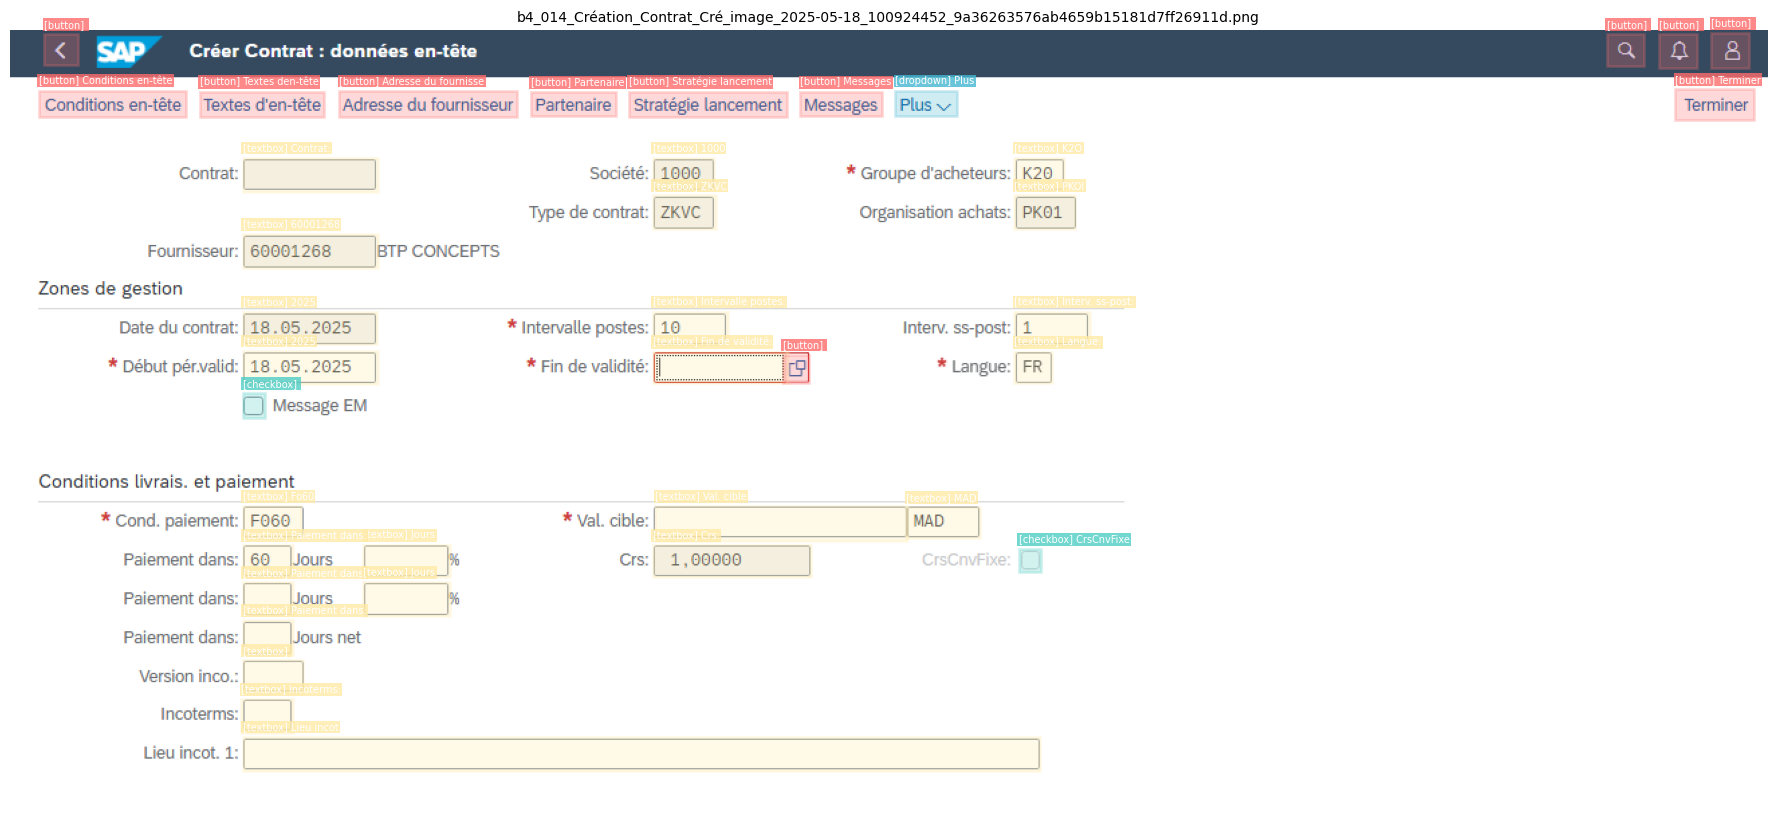


Analyse : b4_018_Création_Contrat_Cré_image_2025-05-18_101820936_6f9fd47f7a5945189097f0c7ca52f236.png


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


   OCR : 55 blocs bruts → 48 blocs mergés
   YOLO skippé — layout similaire, cache réutilisé

   Type            Label                          Value                     Conf
   --------------------------------------------------------------------------------
   textbox         Crs:                                                     0.912
   textbox         Contrat:                                                 0.903
   textbox         Foumisseur: 60001268           60001268                  0.902
   textbox         Groupe dacheteurs:                                       0.902
   textbox         Jours                                                    0.902
   textbox         Organisation achats: PKOI      PKOI                      0.9
   textbox         Paiement dans:                                           0.9
   textbox         000 . 000                      MAD                       0.897
   textbox         Jours                                                    0.896
   text

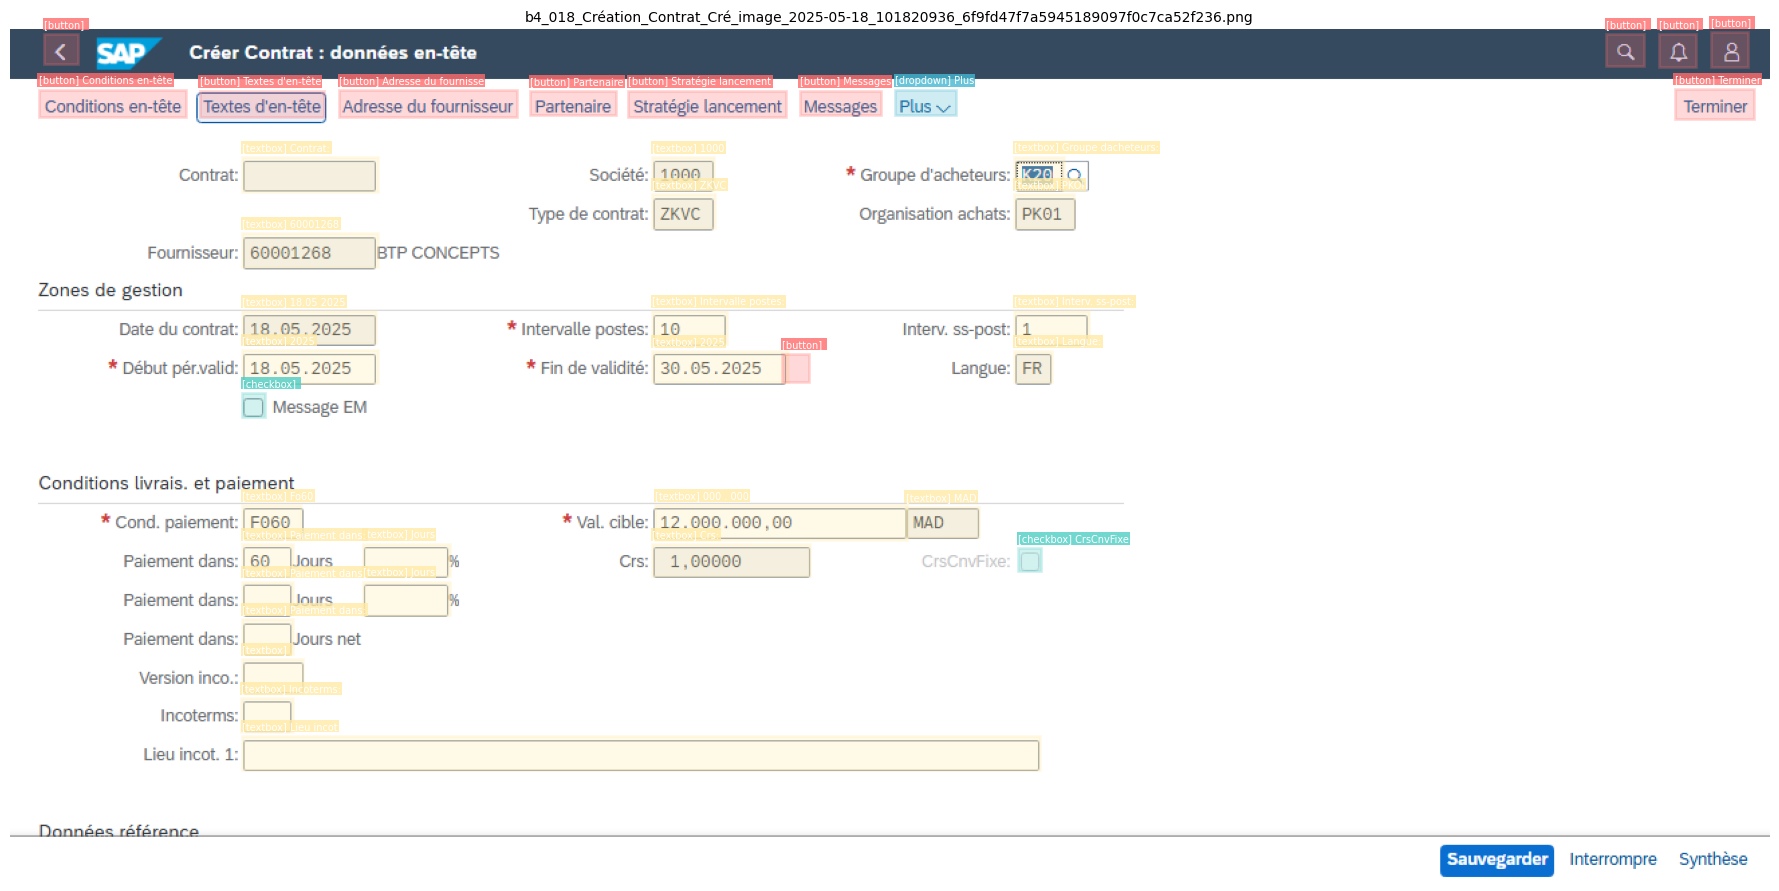

In [19]:
test_screens = [
    '/content/drive/MyDrive/PAbatchesfolder/test_pipeline_3/b4_014_Création_Contrat_Cré_image_2025-05-18_100924452_9a36263576ab4659b15181d7ff26911d.png',
    '/content/drive/MyDrive/PAbatchesfolder/test_pipeline_3/b4_018_Création_Contrat_Cré_image_2025-05-18_101820936_6f9fd47f7a5945189097f0c7ca52f236.png',
]

prev_path     = None
prev_elements = None

for screen in test_screens:
    elements, tb_raw, tb_merged = analyze_screenshot_smart(
        screen,
        prev_image_path = prev_path,
        cached_elements = prev_elements,
        show_viz        = True,
        save            = True
    )
    prev_path     = screen
    prev_elements = elements

---
## RUN PIPELINE COMPLET

4 events chargés depuis /content/drive/MyDrive/PAbatchesfolder/test_pipeline/events.json
Pass 1 — Analyse de tous les screens...

Analyse : b4_044_Création_d_article_C_Article_28_FZE_Img2_533805c259574870921243884e20838a.png


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


   OCR : 15 blocs bruts → 15 blocs mergés
   YOLO lancé — nouveau layout détecté
   YOLO : 18 éléments détectés

   Type            Label                          Value                     Conf
   --------------------------------------------------------------------------------
   textbox                                                                  0.895
   button                                         Terminer                  0.861
   button                                         Sunte                     0.86
   dropdown        Type jaruicle:                                           0.86
   dropdown        Branche                                                  0.851
   textbox         Article:                                                 0.844
   textbox                                                                  0.839
   button                                         Sélection des vues        0.838
   textbox         Bravo                                            

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


   OCR : 32 blocs bruts → 31 blocs mergés
   YOLO lancé — nouveau layout détecté
   YOLO : 46 éléments détectés

   Type            Label                          Value                     Conf
   --------------------------------------------------------------------------------
   popup                                          Sélection des vues Vue Gestion emplacements magasin 1 Gestion emplacements magasin  Monogement qualte Comptabilité Comptabilité exécution Données valorisation segment Select des vues uniquement sur demande CreervuesMarouees Niveaux organisation Données 8Paramétrage 0.947
   button                                         Données                   0.853
   button                                                                   0.828
   button                                         8Paramétrage              0.824
   button                                                                   0.812
   button                                         Niveaux organisation  

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


   OCR : 38 blocs bruts → 36 blocs mergés
   YOLO lancé — nouveau layout détecté
   YOLO : 45 éléments détectés

   Type            Label                          Value                     Conf
   --------------------------------------------------------------------------------
   popup                                          Sélection des vues Vue Classification Donnees Qe base SPPetenques Achats Importations Texte de commande dachat Plenification des besoins Plenification des besoins Plenification des Plenification des besoins Plenification étendue Previsions Préparation du travail Données gén. divis {stockage Données gén. divis Istockage Gesuon emplacements magasin 1 Sélect Oes vues uniquement sur demande Creer vues Marouees Niveaux organisation Données Paramérrage 0.948
   button                                         Niveaux organisation      0.809
   button                                         Paramérrage               0.779
   button                                         D

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


   OCR : 24 blocs bruts → 22 blocs mergés
   YOLO lancé — nouveau layout détecté
   YOLO : 27 éléments détectés

   Type            Label                          Value                     Conf
   --------------------------------------------------------------------------------
   popup                                          Nvx organisationnels Nvx organisationnels Division; emande Selection des vues Paramétrage 0.933
   textbox                                                                  0.824
   textbox         Division;                                                0.814
   button                                         Paramétrage               0.811
   button                                         Selection des vues        0.776
   button                                                                   0.747
   button                                                                   0.741
   checkbox                                                                 0.739
  

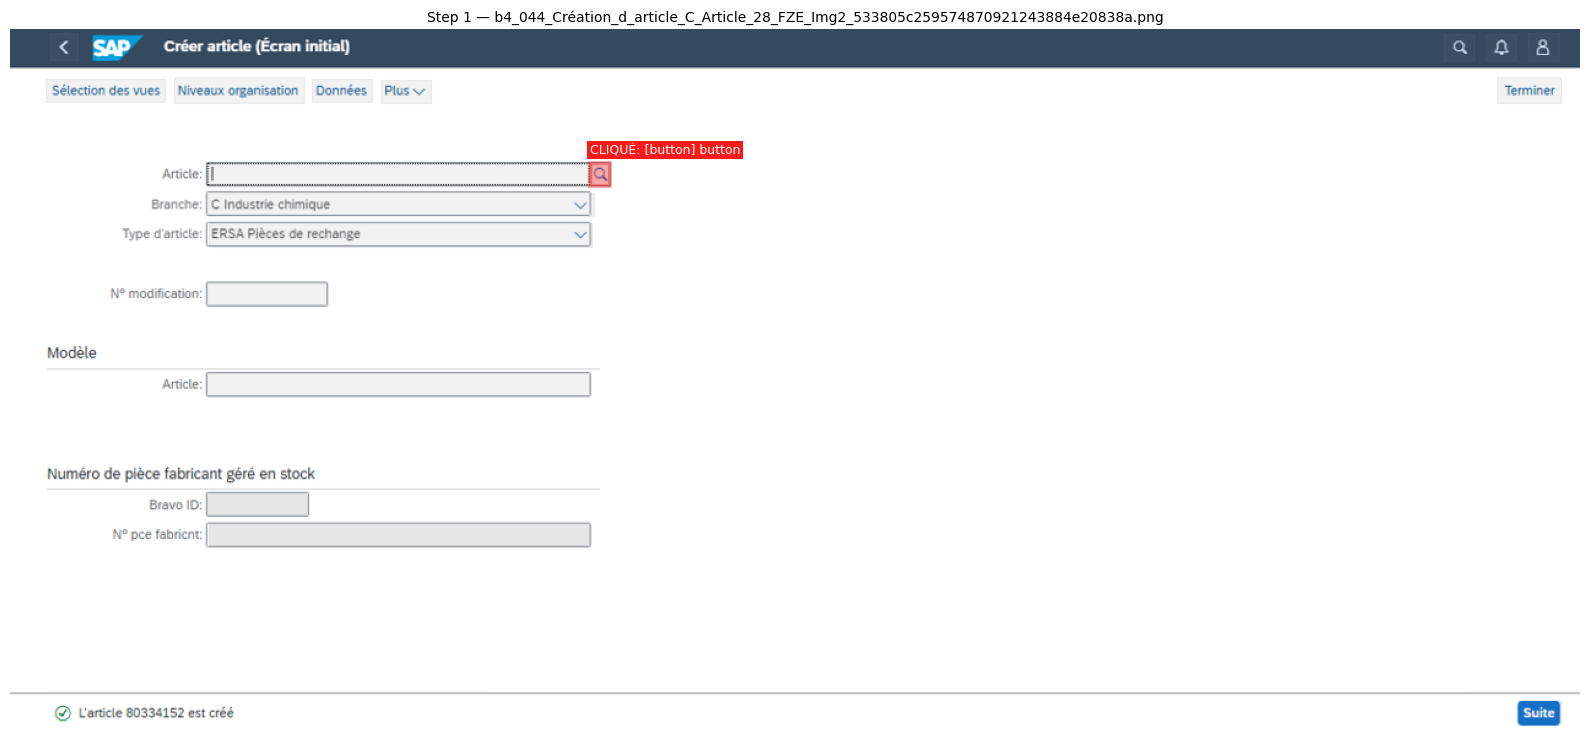


Event 2 — [checkbox] 
   Nouvelle collection créée : collection_0


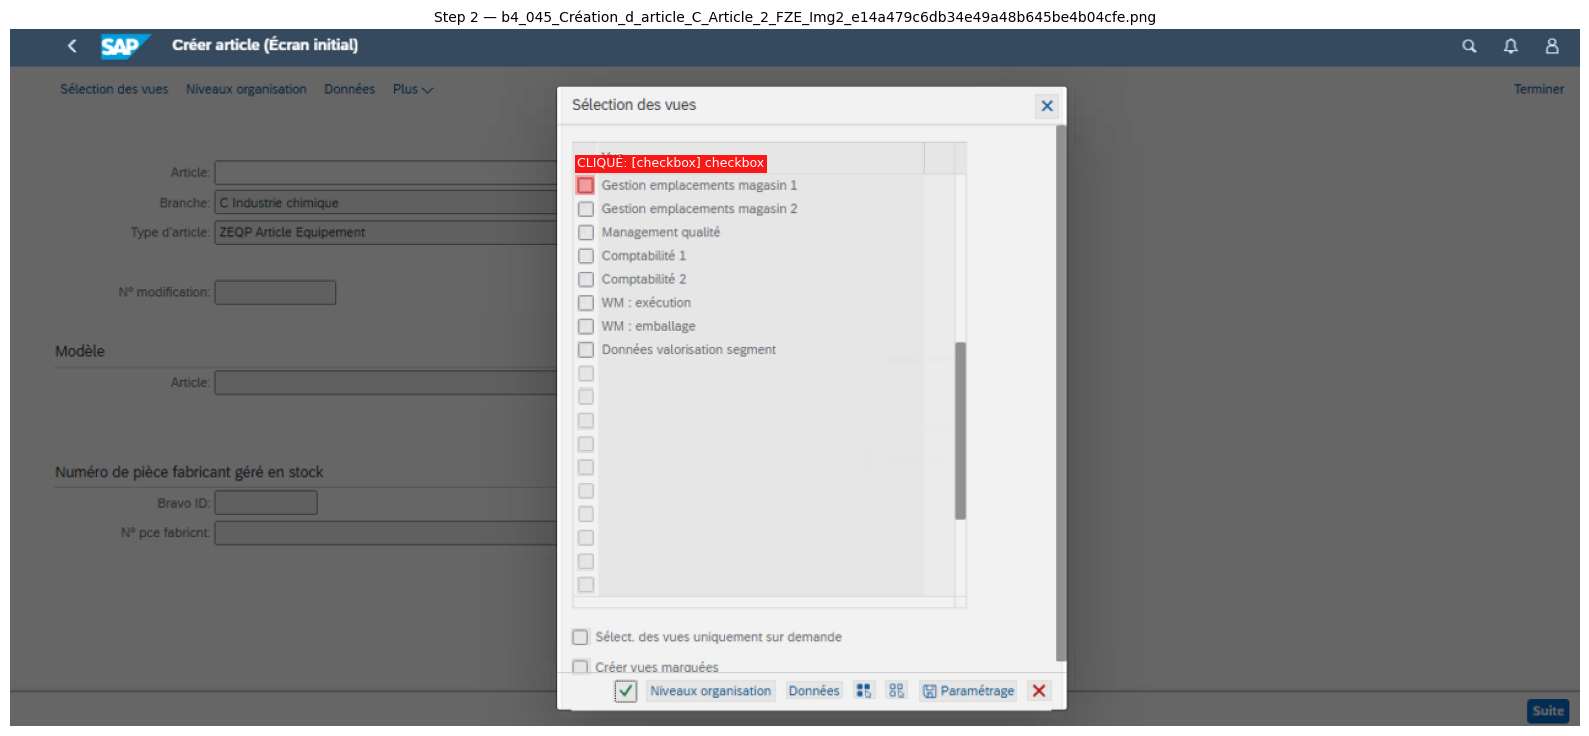


Event 3 — [button] Niveaux organisation
   Nouvelle collection créée : collection_1


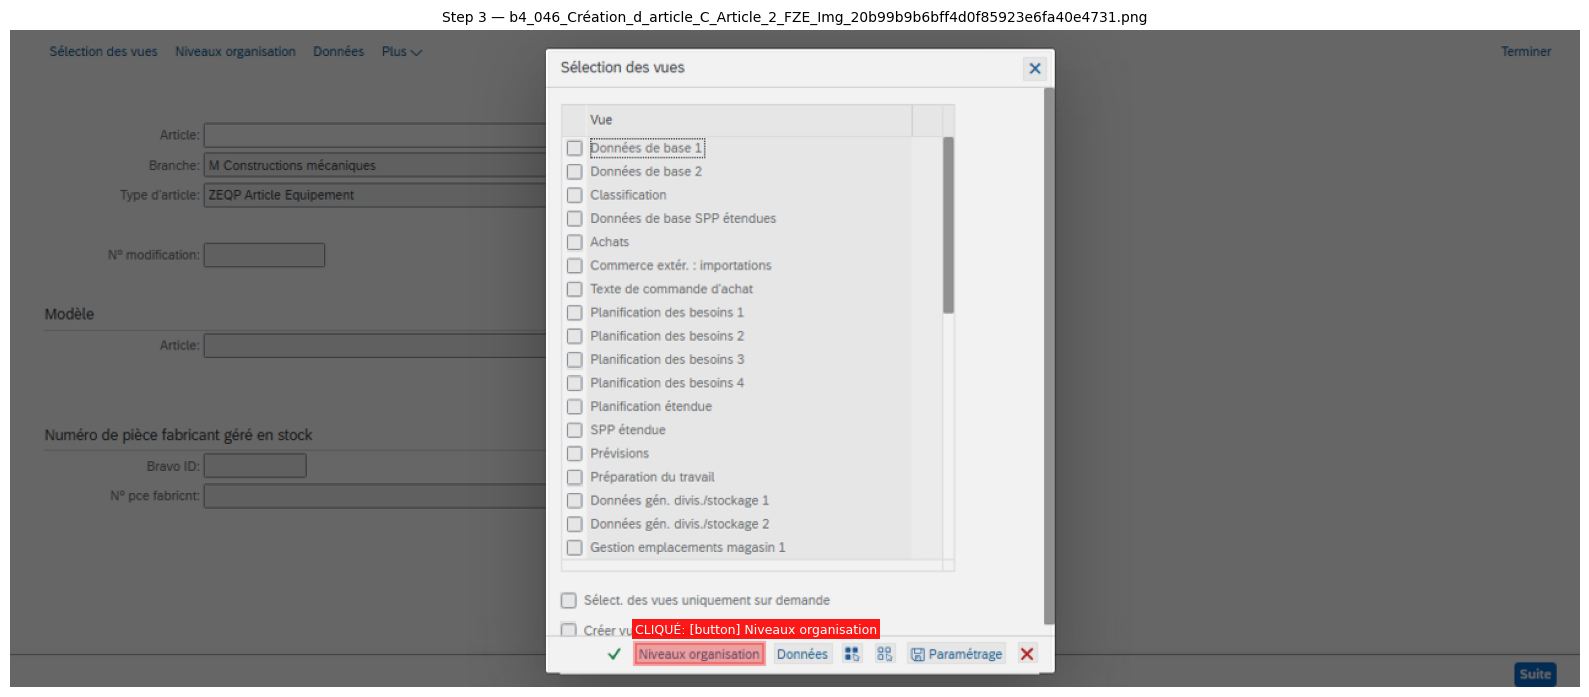


Event 4 — [button] 
   Nouvelle collection créée : collection_2


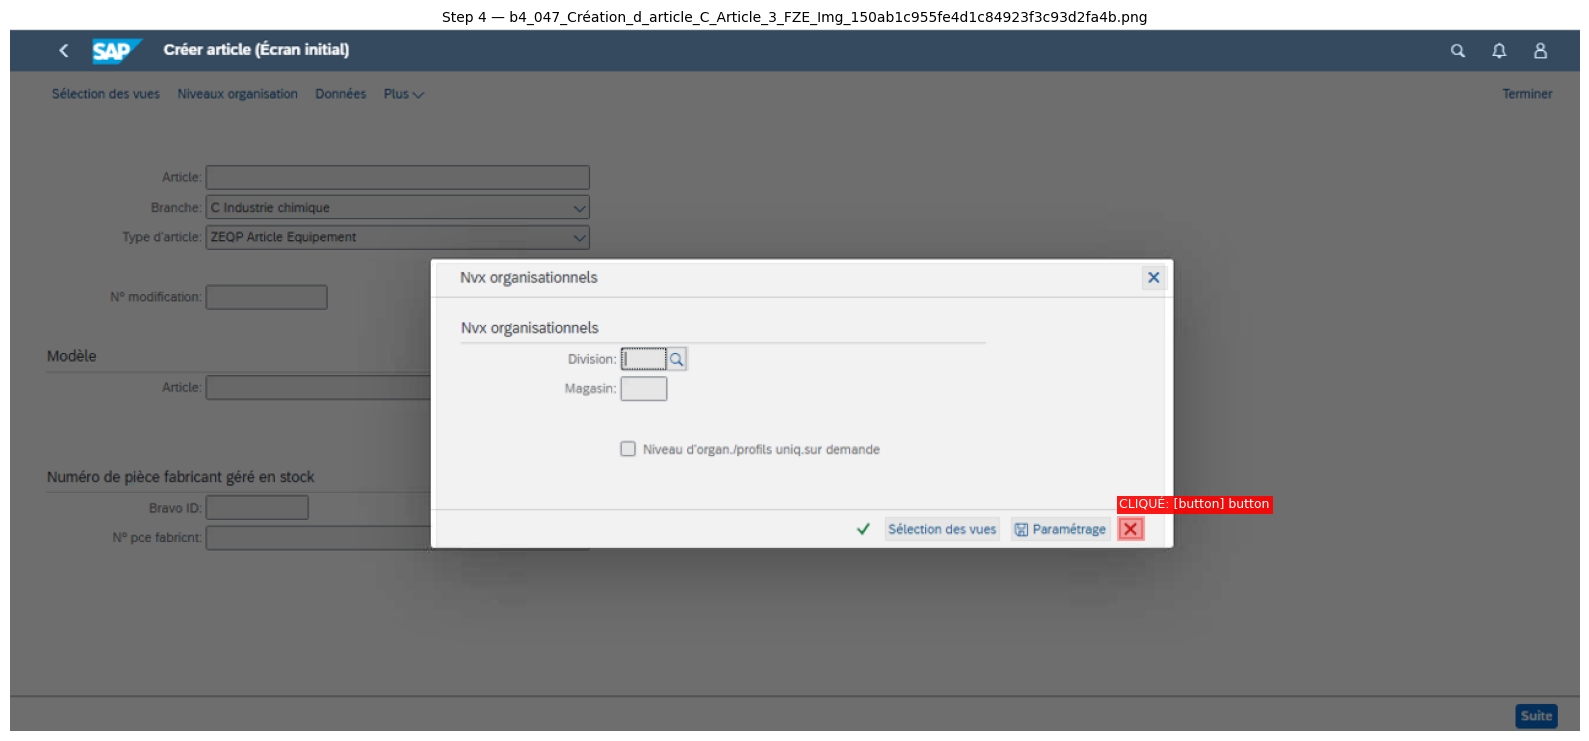


4 collections générées, 4 steps total

JSON Ederest généré !
   4 collections
   4 steps
   Sauvegardé : /content/drive/MyDrive/PAbatchesfolder/test_pipeline/simulation_ederest.json

JSON Ederest généré :
{
  "title": "Simulation SAP",
  "platform": "SAP",
  "language": "fr",
  "formation_type": "TUTORIAL",
  "difficulty": "beginner",
  "total_step_count": 4,
  "total_image_count": 4,
  "collections": [
    {
      "collection_id": "collection_0",
      "collection_type": "interactive",
      "sequence": 0,
      "required": true,
      "interactive_images": [
        {
          "image_id": "step_0_click",
          "sequence": 0,
          "image": "b4_044_Création_d_article_C_Article_28_FZE_Img2_533805c259574870921243884e20838a.png",
          "instruction": "Cliquez sur button",
          "screenshot_width": 1280,
          "screenshot_height": 570,
          "fields": [
            {
              "field_id": "step_0_field_0",
              "name": "textbox",
              "field

In [22]:
result = generate_ederest_json_final(
    events_path     = EVENTS_PATH,
    screenshots_dir = SCREENSHOTS_DIR,
    output_path     = OUTPUT_JSON
)

print('\nJSON Ederest généré :')
print(json.dumps(result, ensure_ascii=False, indent=2))

---
## Export ONNX (optionnel)

In [ ]:
model_export = YOLO(YOLO_MODEL_PATH)
model_export.export(format='onnx', imgsz=640, simplify=True, opset=12)
print('Modèle exporté en ONNX !')
print('Le fichier .onnx est dans le même dossier que le .pt')